<h1>Analisis actividad 12: Jump front & back</h1>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import seaborn as sns


In [2]:
actividad = 12

In [3]:
actividades = {
    1: "Standing still",
    2: "Sitting and relaxing",
    3: "Lying down",
    4: "Walking",
    5: "Climbing stairs",
    6: "Waist bends forward",
    7: "Frontal elevation of arms",
    8: "Knees bending",
    9: "Cycling",
    10: "Jogging",
    11: "Running",
    12: "Jump front & back"
}

<h1>Carga de Dataset</h1>

In [4]:

import glob
import pandas as pd
import re

# Busca todos los archivos
files = glob.glob(r"../DataSets/MHEALTHDATASET/mHealth_subject*.log")

dfs = []

for file in files:
    
    # Extraer número de sujeto desde el nombre del archivo
    subject_id = int(re.search(r"subject(\d+)", file).group(1))
    
    # Leer archivo
    df = pd.read_csv(file, sep='\t', header=None)
    
    # Agregar columna subject_id
    df["subject_id"] = subject_id
    
    dfs.append(df)

# Unir todos
MHEALTHDATASET = pd.concat(dfs, ignore_index=True)

# Asignar nombres de columnas
MHEALTHDATASET.columns = [  
    # Chest sensor
    "chest_acc_x",
    "chest_acc_y",
    "chest_acc_z",
    "ecg_1",
    "ecg_2",

    # Left ankle
    "ankle_acc_x",
    "ankle_acc_y",
    "ankle_acc_z",
    "ankle_gyro_x",
    "ankle_gyro_y",
    "ankle_gyro_z",
    "ankle_mag_x",
    "ankle_mag_y",
    "ankle_mag_z",

    # Right lower arm
    "arm_acc_x",
    "arm_acc_y",
    "arm_acc_z",
    "arm_gyro_x",
    "arm_gyro_y",
    "arm_gyro_z",
    "arm_mag_x",
    "arm_mag_y",
    "arm_mag_z",

    # Label
    "activity_label",
    
    # Nuevo
    "subject_id"
]

pd.set_option('display.max_columns', None)


In [5]:
## Filtramos para mostrar la actividad 
DATASET_ACTIVIDAD = MHEALTHDATASET[MHEALTHDATASET['activity_label'] == actividad]

# Le quitamos las etiquetas
DATASET_SENSORES_ACTIVIDAD = DATASET_ACTIVIDAD.drop(columns=['activity_label'])

<h1>Correlación entre los atributos</h1>

In [6]:

DATASET_SENSORES_ACTIVIDAD.corr()

,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,subject_id
chest_acc_x,1.000000,0.116714,0.549805,-0.065836,-0.067632,-0.001337,0.429264,0.094224,-0.026762,-0.095478,0.111294,-0.038957,-0.017831,0.012513,0.475018,0.343498,-0.341698,-0.011320,0.116412,0.055113,-0.029674,0.023868,-0.266522,0.011883
chest_acc_y,0.116714,1.000000,-0.090103,0.035709,-0.000986,-0.010051,0.013649,-0.037099,0.074660,-0.032675,0.053974,-0.040285,-0.011328,-0.011211,0.015948,0.011070,-0.003285,-0.004926,-0.001239,0.081761,0.048642,-0.008703,-0.048236,-0.040695
chest_acc_z,0.549805,-0.090103,1.000000,-0.072015,-0.066966,0.039039,0.343167,0.094804,-0.145109,-0.017685,-0.018110,-0.002137,-0.008465,0.028879,0.402101,0.321117,-0.337946,-0.006343,0.074835,-0.161844,-0.094746,-0.034037,-0.101127,0.055219
ecg_1,-0.065836,0.035709,-0.072015,1.000000,0.644745,0.028654,-0.048386,-0.015157,-0.050977,-0.050051,0.102368,0.031109,-0.045072,0.017181,-0.041391,-0.077068,0.021443,-0.135705,-0.129700,-0.071569,-0.002603,-0.029033,0.060365,0.141842
ecg_2,-0.067632,-0.000986,-0.066966,0.644745,1.000000,0.001736,-0.048542,-0.023671,-0.186109,-0.012990,-0.069506,0.033110,-0.024572,-0.006289,-0.058907,-0.063113,0.022135,-0.114799,-0.082750,-0.181847,0.014917,-0.009914,0.041337,0.040482
ankle_acc_x,-0.001337,-0.010051,0.039039,0.028654,0.001736,1.000000,0.015278,-0.192998,-0.036926,0.003343,-0.003417,-0.021944,-0.250068,-0.123454,0.078817,0.033861,-0.009152,0.024596,-0.030732,-0.042486,-0.046876,-0.014628,0.022582,0.070135
ankle_acc_y,0.429264,0.013649,0.343167,-0.048386,-0.048542,0.015278,1.000000,-0.042060,0.005969,-0.110509,0.082772,-0.129647,0.029356,-0.037380,0.514486,0.327235,-0.260220,0.015447,0.104849,0.051445,-0.042787,0.051739,-0.235978,0.019739
ankle_acc_z,0.094224,-0.037099,0.094804,-0.015157,-0.023671,-0.192998,-0.042060,1.000000,0.001689,0.044113,-0.065048,-0.038706,0.189866,0.041051,0.108162,0.101862,-0.028619,0.029766,0.001896,0.011922,0.085595,-0.014922,0.059439,0.017613
ankle_gyro_x,-0.026762,0.074660,-0.145109,-0.050977,-0.186109,-0.036926,0.005969,0.001689,1.000000,0.020571,0.234626,0.017086,-0.011847,0.018864,-0.066529,0.014822,0.095417,0.425553,-0.057000,0.761099,0.024388,-0.015537,0.009623,0.072311
ankle_gyro_y,-0.095478,-0.032675,-0.017685,-0.050051,-0.012990,0.003343,-0.110509,0.044113,0.020571,1.000000,-0.481769,0.095577,-0.001692,0.037910,-0.149803,0.001274,0.072273,0.013727,-0.282670,-0.187419,0.048683,-0.045862,0.113346,0.095651


<h1>Histograma de la Actividad</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

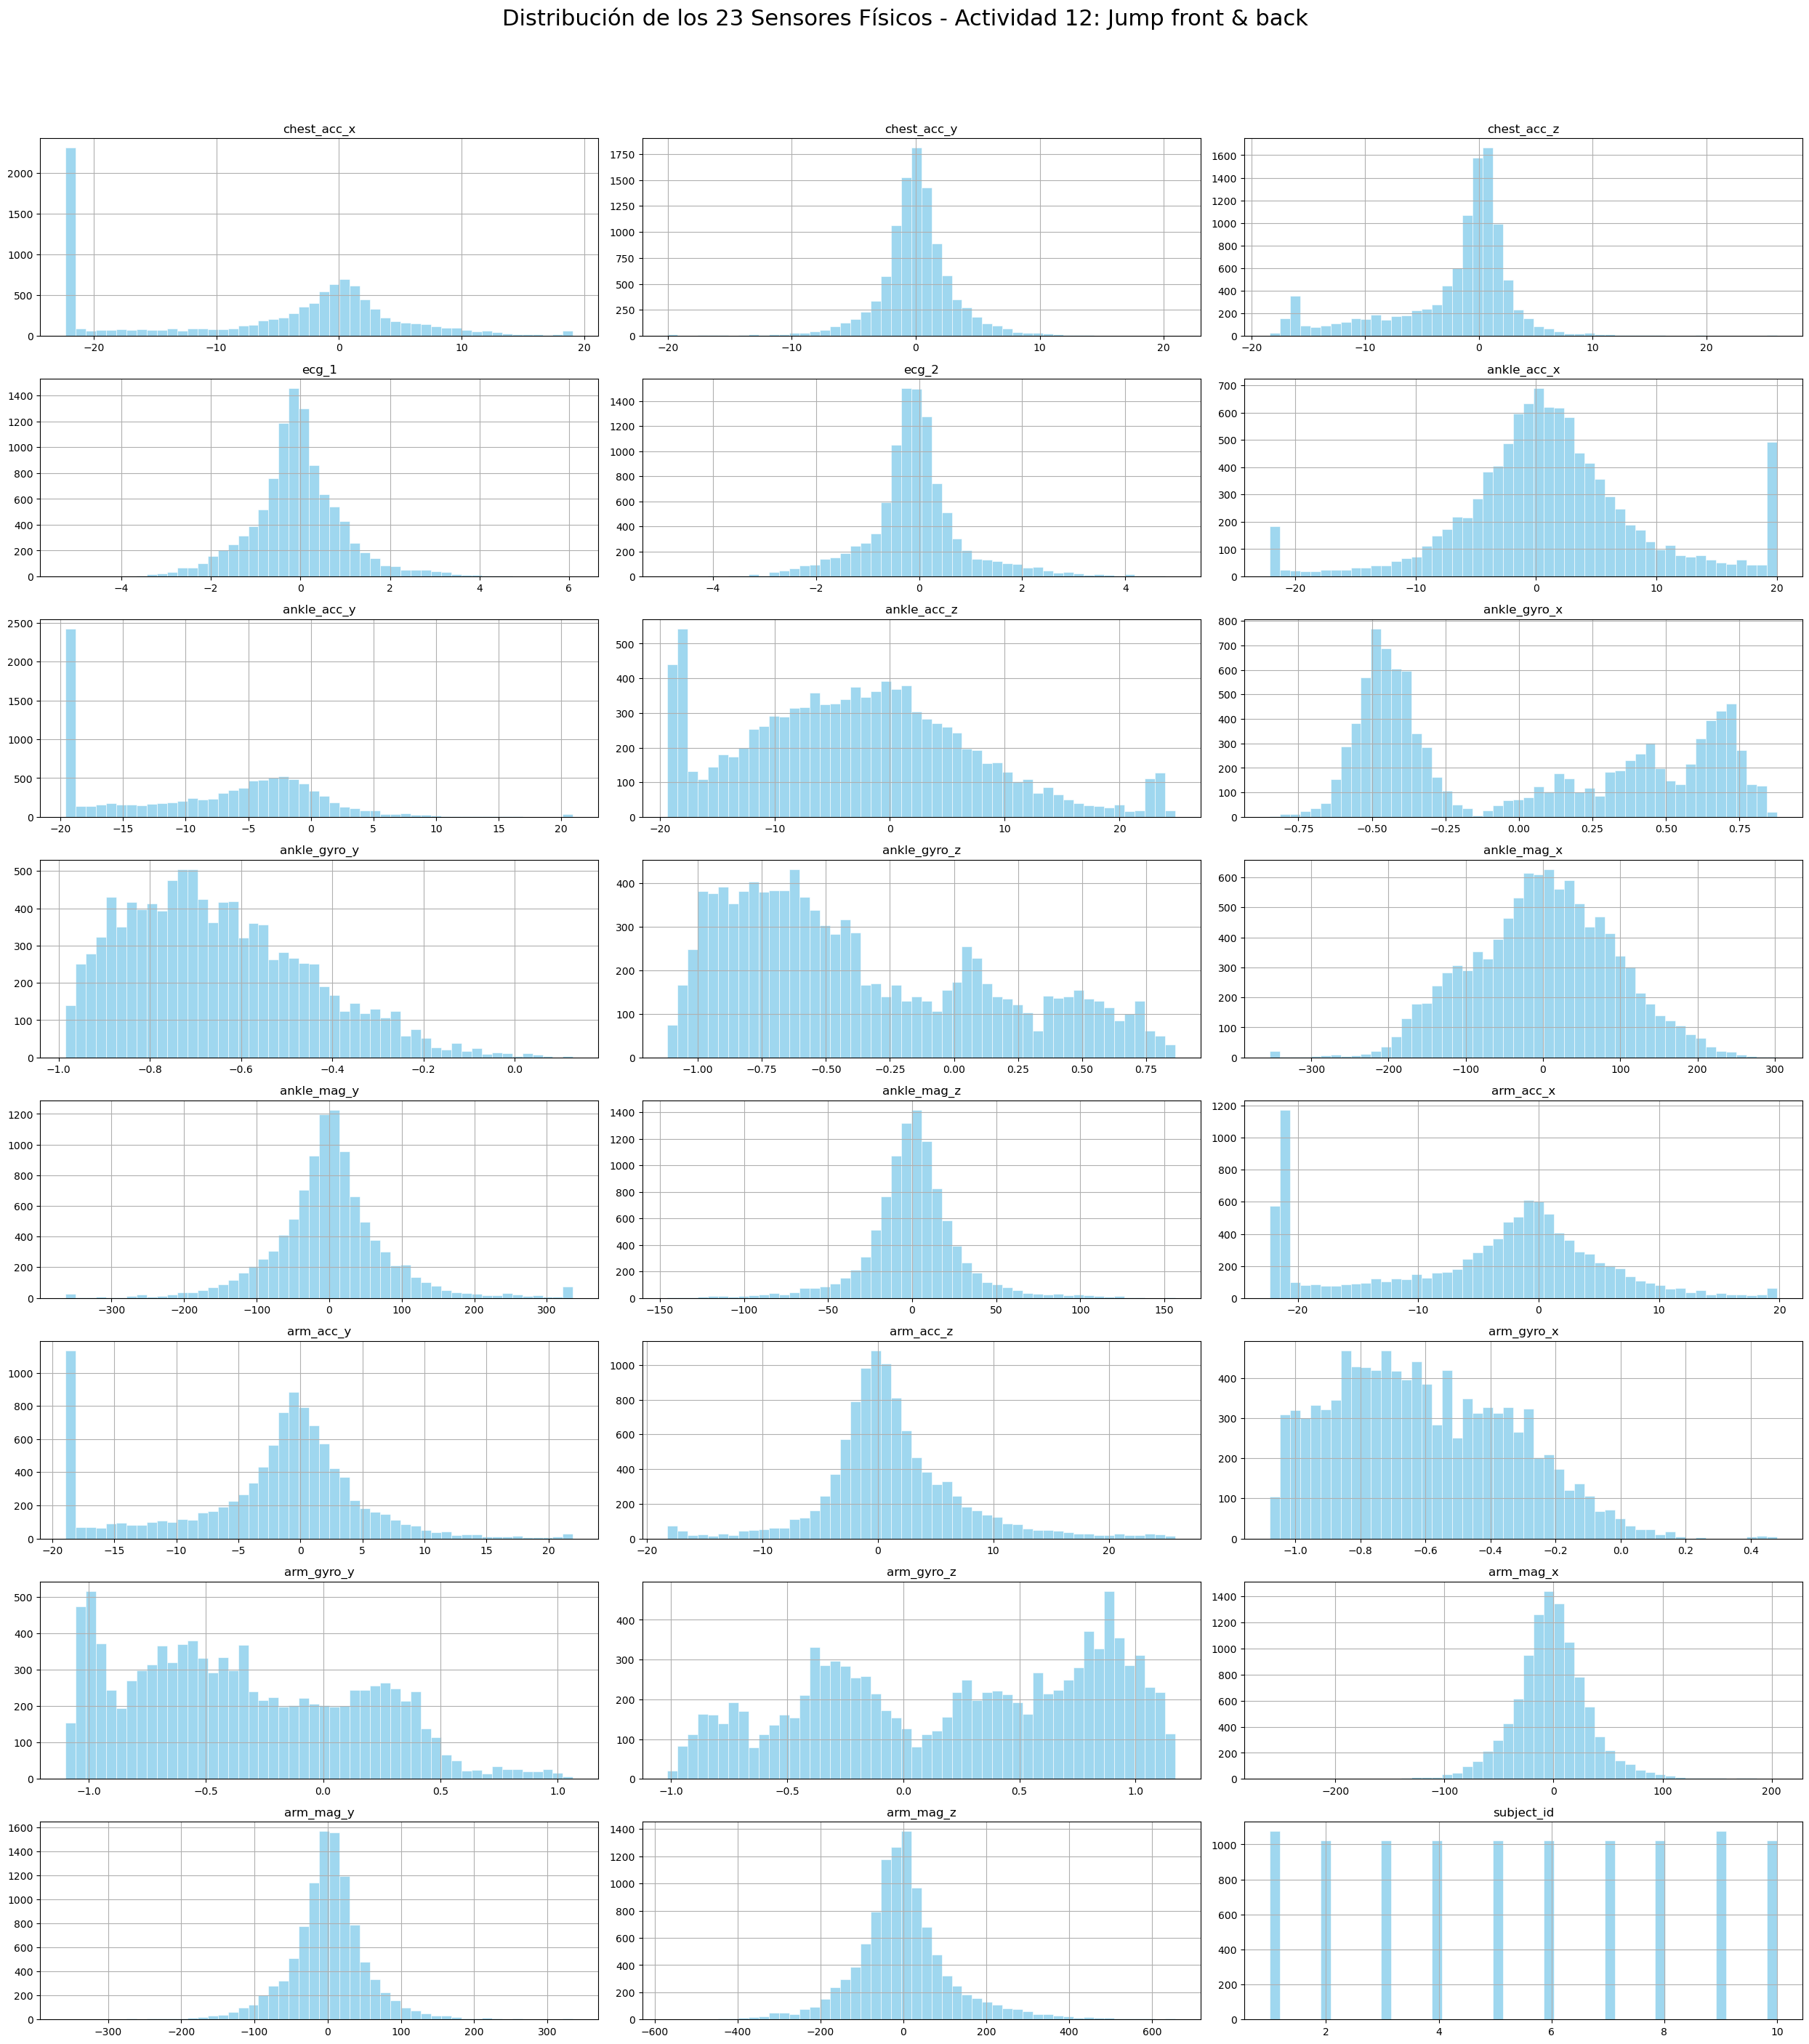

In [7]:


DATASET_SENSORES_ACTIVIDAD.hist(
    bins=50, 
    layout=(15,3),
    figsize=(25, 50), 
    color='skyblue', 
    edgecolor='white', 
    linewidth=0.5,
    alpha=0.8
)

plt.suptitle(f"Distribución de los 23 Sensores Físicos - Actividad {actividad}: {actividades[actividad]}", fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Outliers</h1>

In [8]:

outliers_info = []

for col in DATASET_SENSORES_ACTIVIDAD.select_dtypes(include="number").columns:
    
    Q1 = DATASET_SENSORES_ACTIVIDAD[col].quantile(0.25)
    Q3 = DATASET_SENSORES_ACTIVIDAD[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    mask_outliers = (DATASET_SENSORES_ACTIVIDAD[col] < lower) | (DATASET_SENSORES_ACTIVIDAD[col] > upper)
    
    total_outliers = mask_outliers.sum()
    percentage = mask_outliers.mean() * 100
    
    outliers_info.append({
        "Sensor": col,
        "Total_Outliers": total_outliers,
        "Porcentaje_Outliers (%)": round(percentage, 2)
    })

outliers_df = pd.DataFrame(outliers_info)

outliers_df

,Sensor,Total_Outliers,Porcentaje_Outliers (%)
0,chest_acc_x,0,0.00
1,chest_acc_y,884,8.55
2,chest_acc_z,1212,11.72
3,ecg_1,699,6.76
4,ecg_2,1286,12.43
5,ankle_acc_x,1019,9.85
6,ankle_acc_y,0,0.00
7,ankle_acc_z,25,0.24
8,ankle_gyro_x,0,0.00
9,ankle_gyro_y,69,0.67


<h1>Gráfica de densidad</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

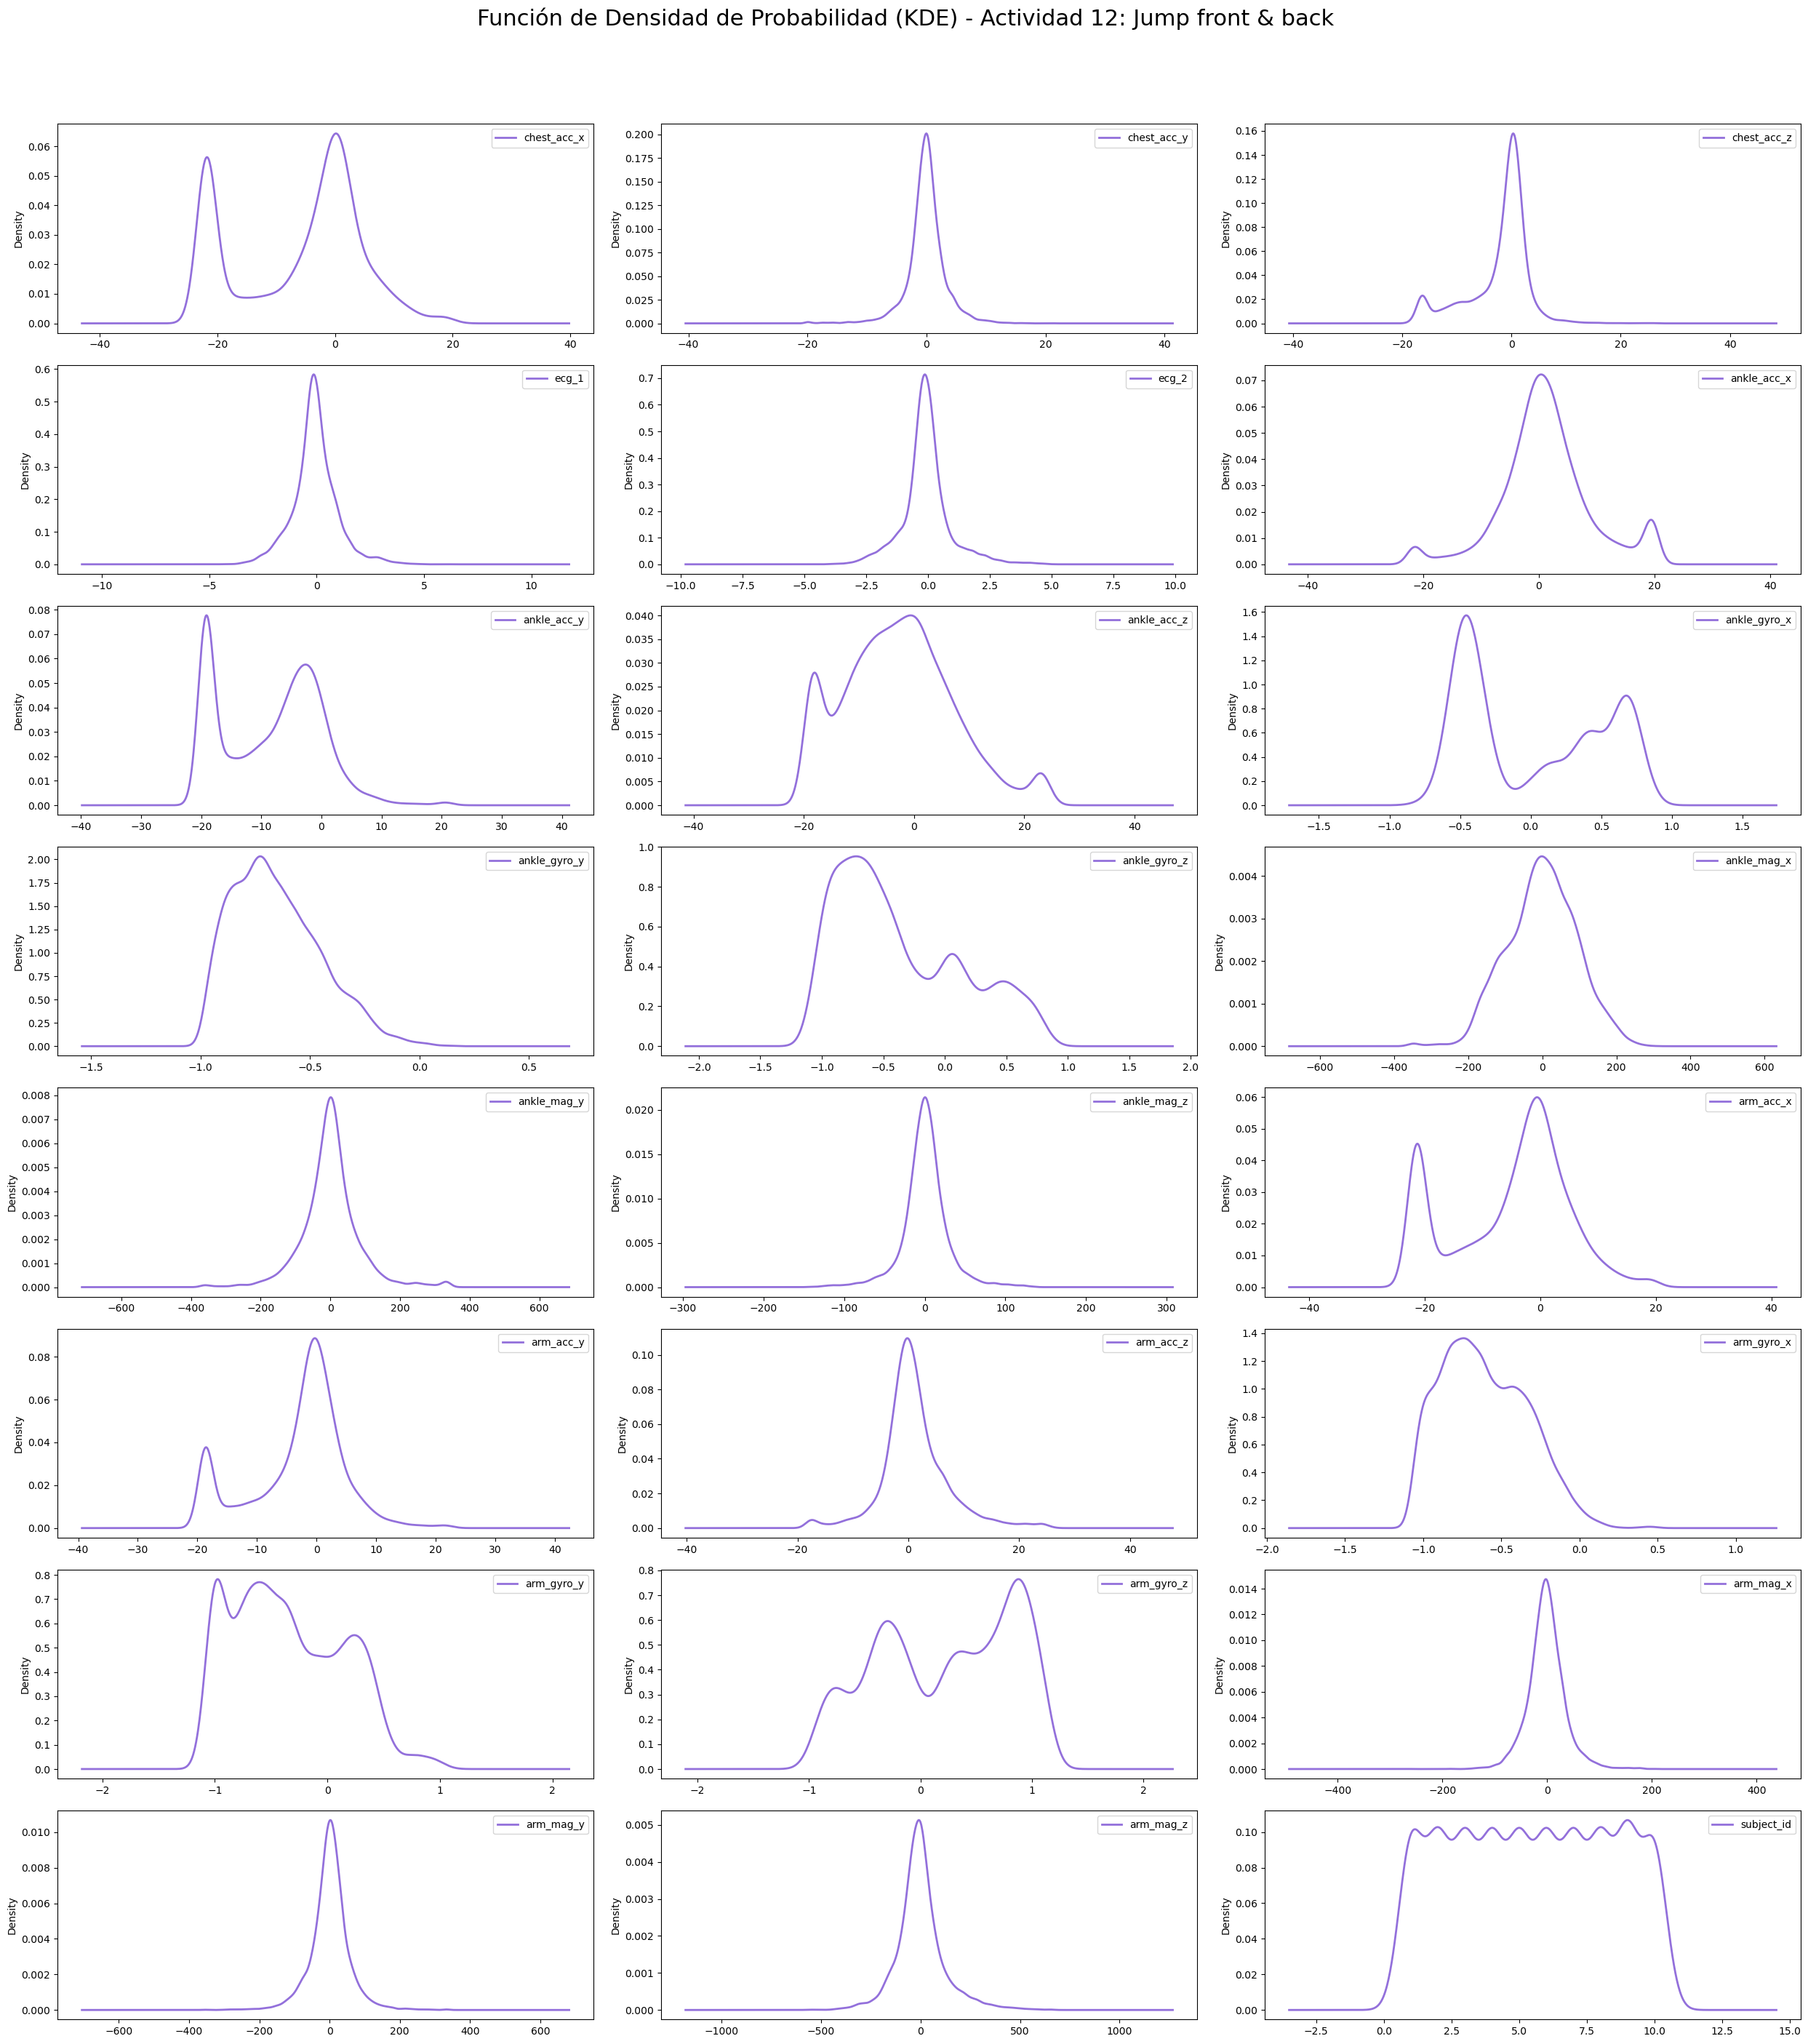

In [9]:
DATASET_SENSORES_ACTIVIDAD.plot(
    kind='density', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(25, 50),
    sharex=False,     
    color='mediumpurple', 
    linewidth=2
)

plt.suptitle(f"Función de Densidad de Probabilidad (KDE) - Actividad {actividad}: {actividades[actividad]}", fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Gráfica de cajas y bigotes</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

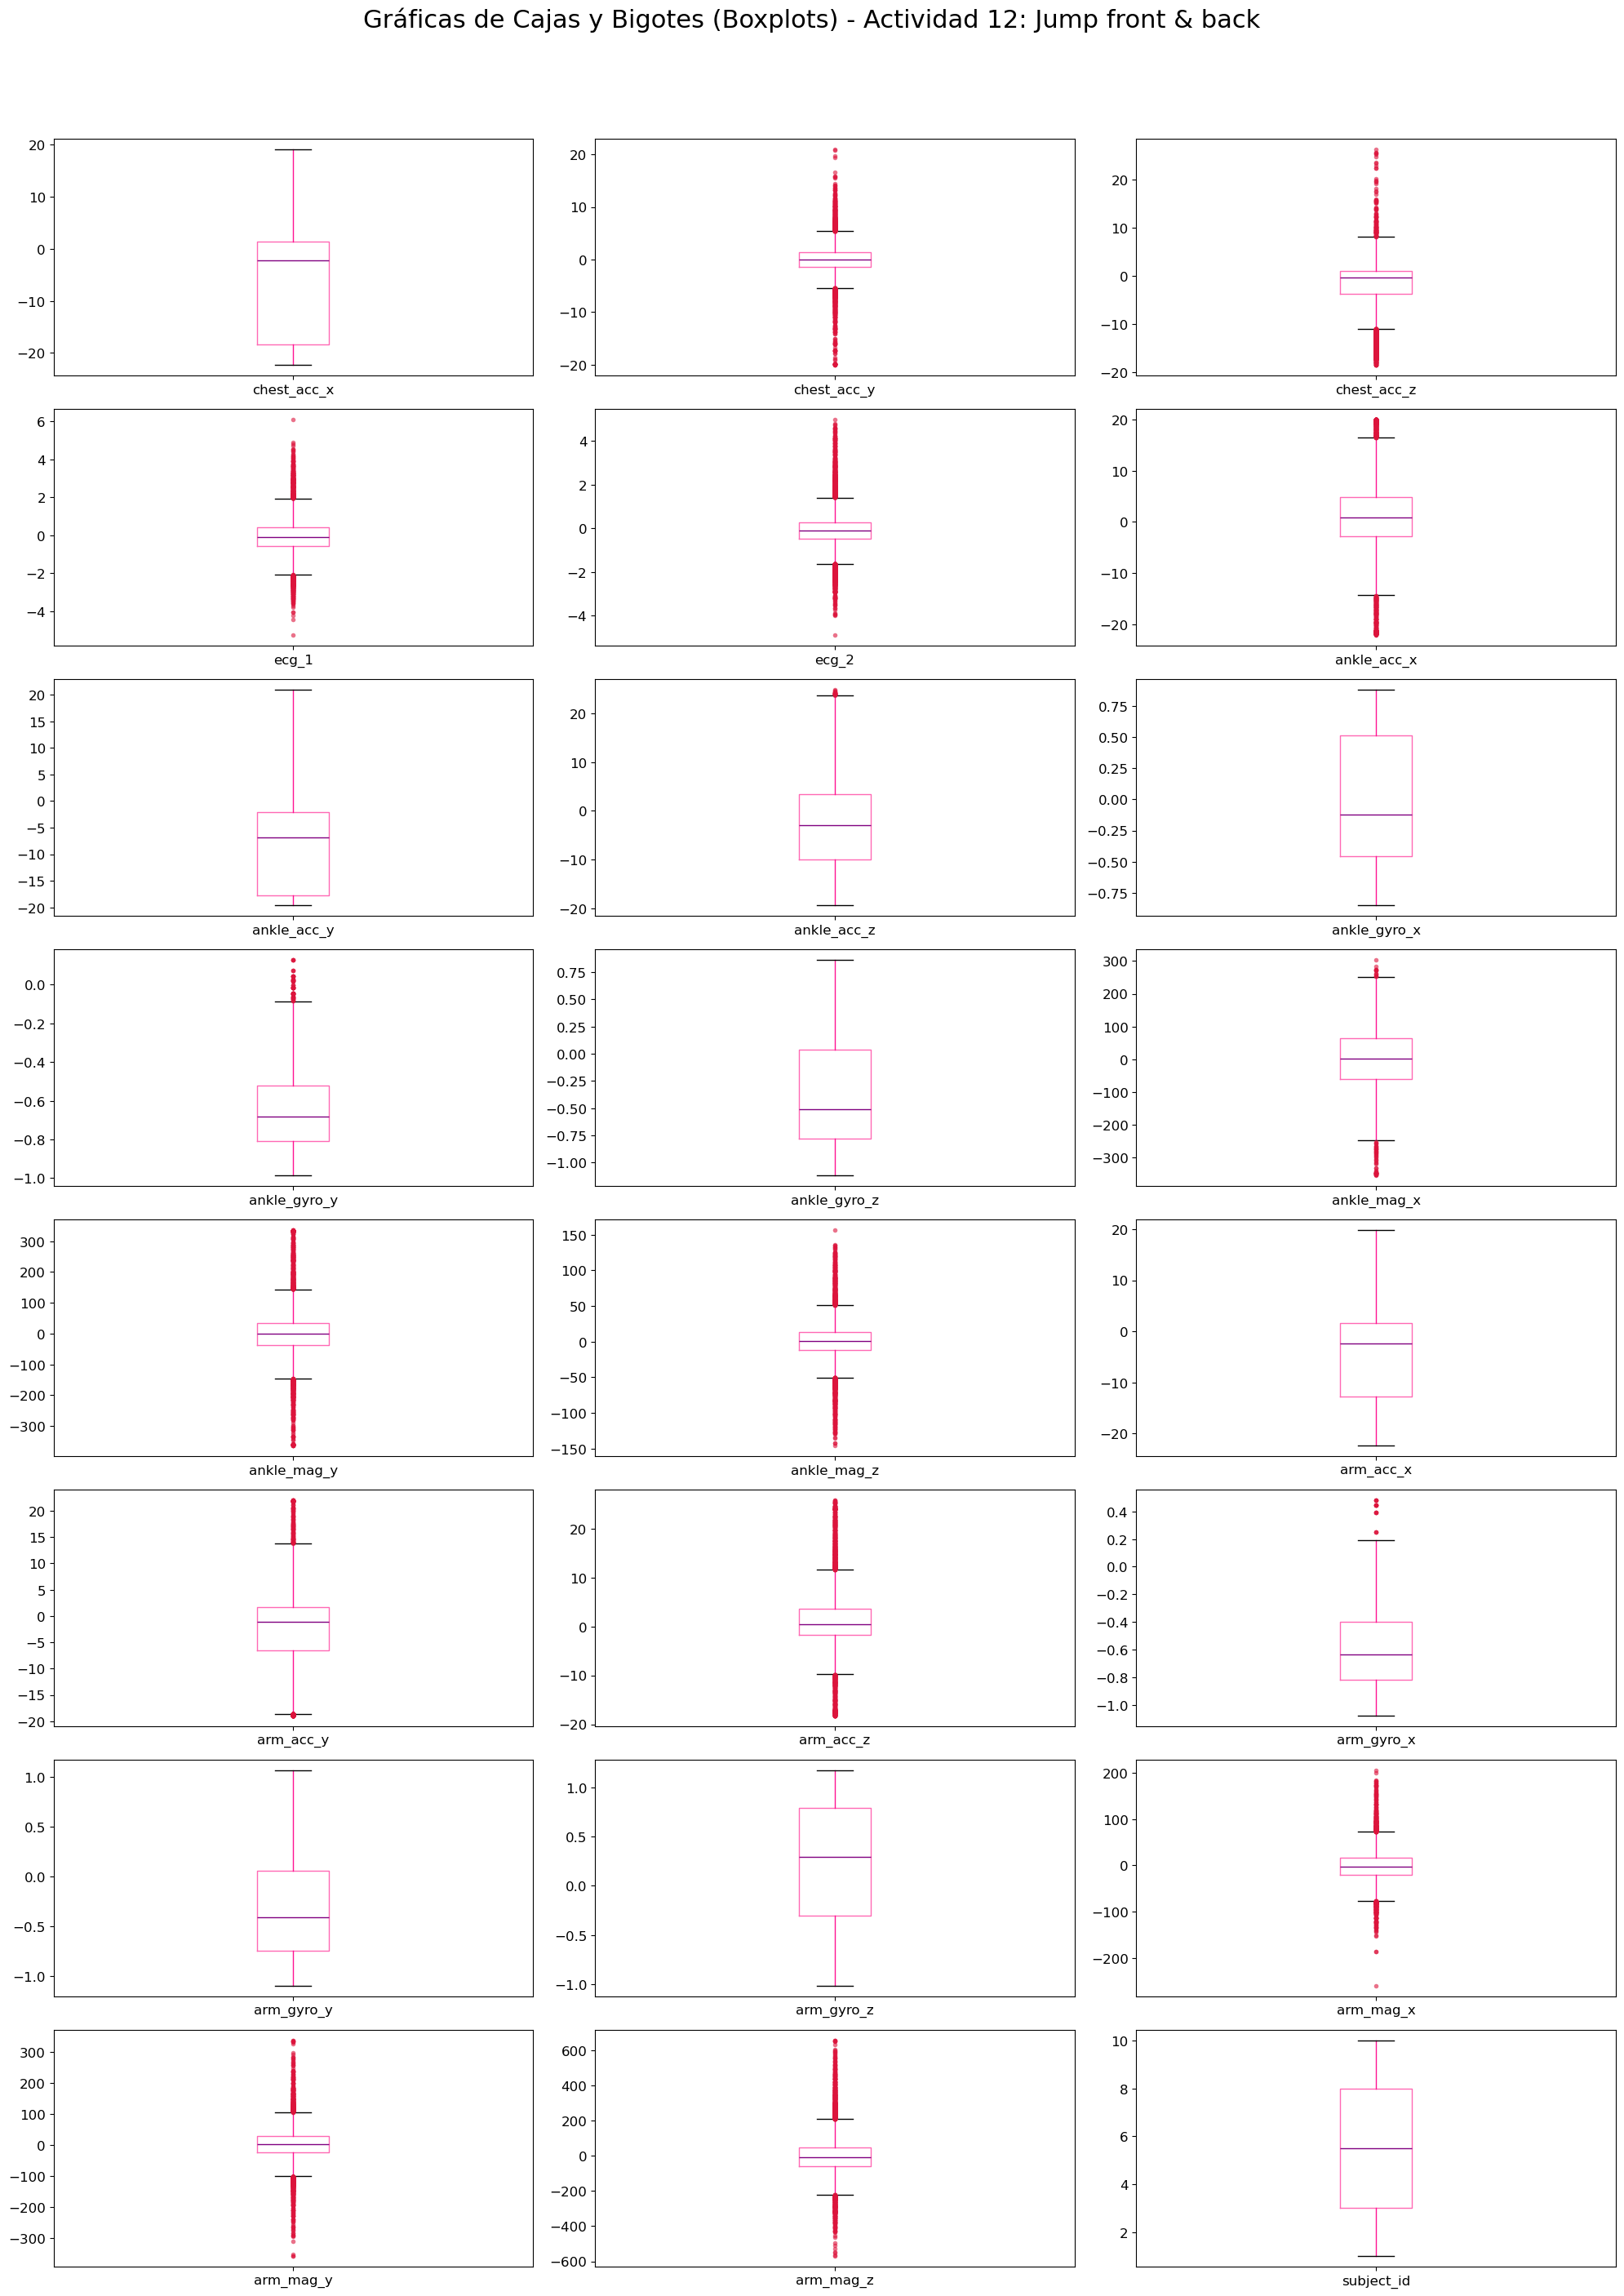

In [10]:
color_props = dict(boxes='hotpink', whiskers='deeppink', medians='purple', caps='black')
puntitos_props = dict(marker='o', markerfacecolor='crimson', markersize=4, alpha=0.6, markeredgecolor='none')

# Dibujamos el mosaico
DATASET_SENSORES_ACTIVIDAD.plot(
    kind='box', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(20, 50), 
    color=color_props,
    flierprops=puntitos_props,
    fontsize=12      
)


plt.suptitle(f'Gráficas de Cajas y Bigotes (Boxplots) - Actividad {actividad}: {actividades[actividad]}', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Matriz de correlación</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

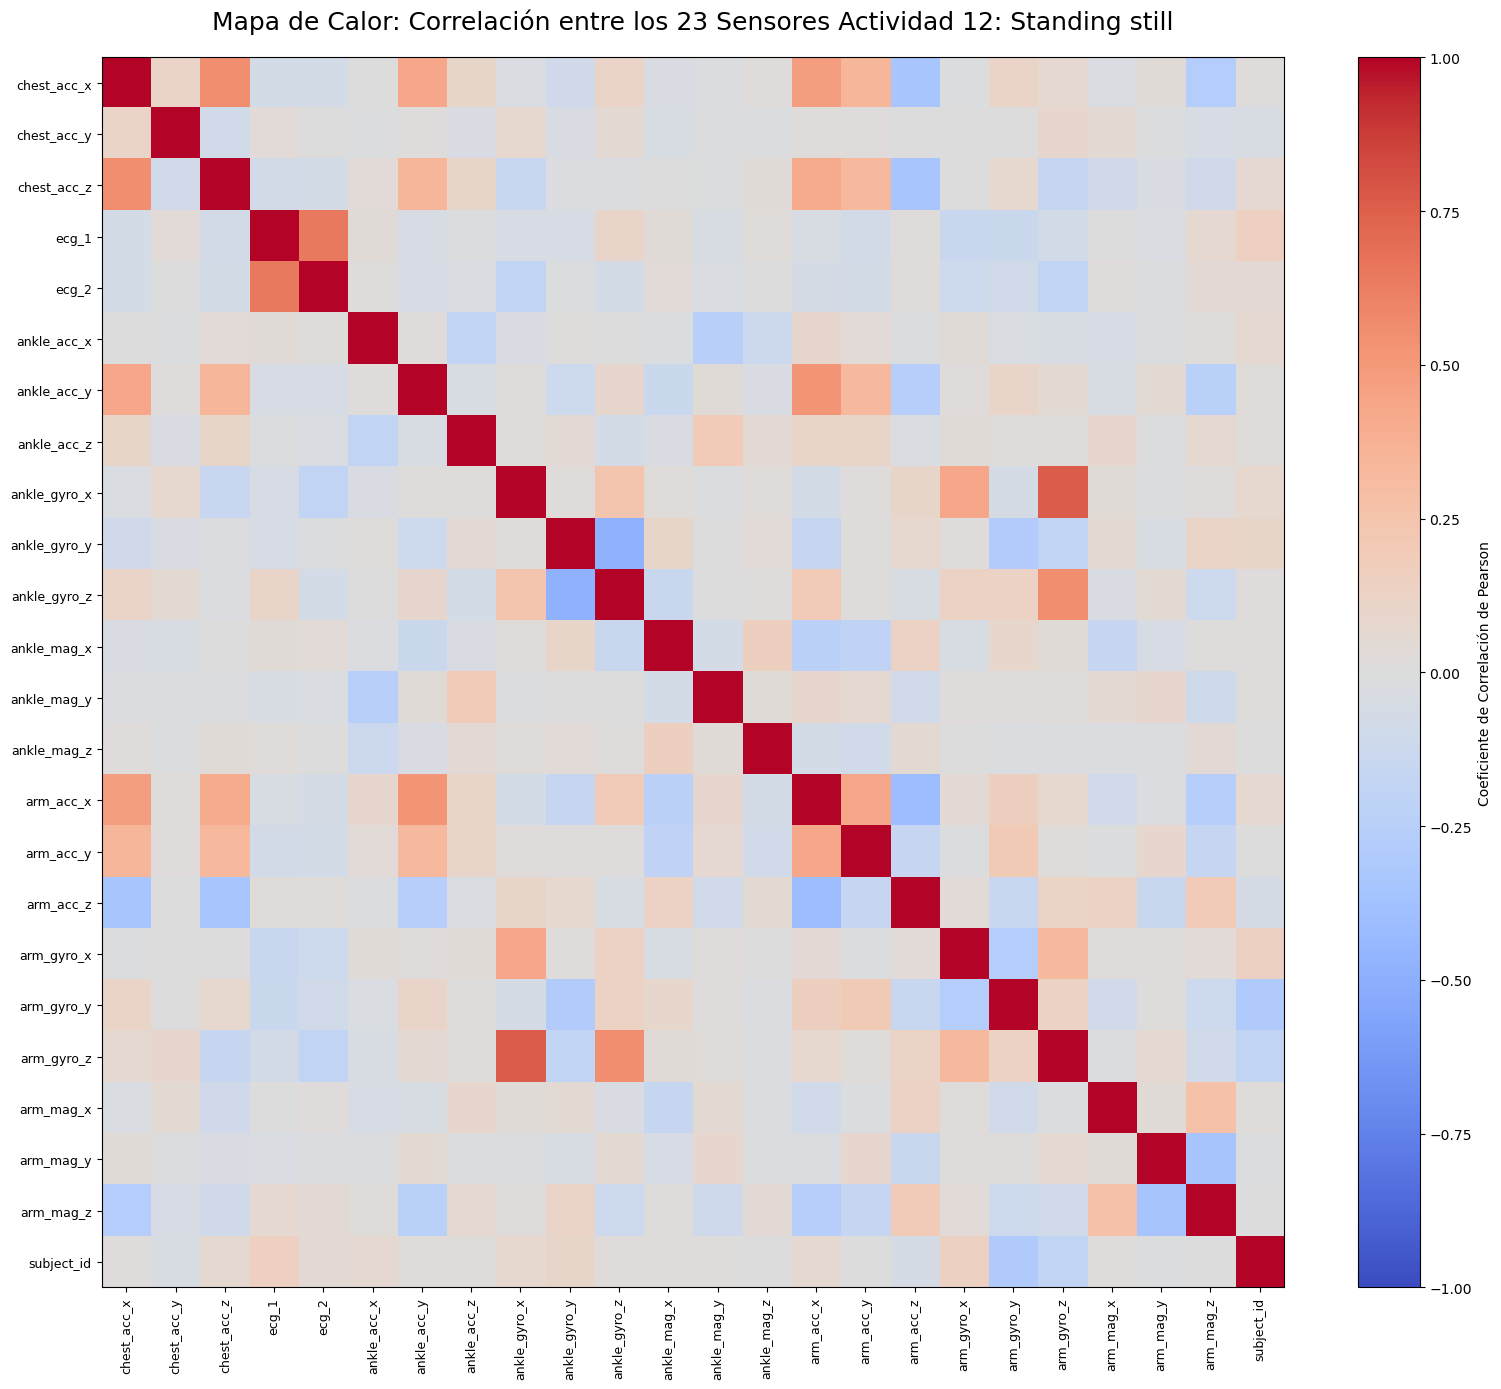

In [11]:
# Calculamos la matriz de correlación de Pearson
matriz_correlacion = DATASET_SENSORES_ACTIVIDAD.corr()

# Dibujamos el Mapa de Calor
plt.figure(figsize=(16, 14))

# Usamos imshow para dibujar la cuadrícula, coolwarm da rojo a los +1 y azul a los -1
imagen = plt.imshow(matriz_correlacion, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

# Agregamos la barra de colores al lado
plt.colorbar(imagen, label='Coeficiente de Correlación de Pearson')
plt.title(f'Mapa de Calor: Correlación entre los 23 Sensores Actividad {actividad}: {actividades[1]}', fontsize=18, pad=20)

# Ponemos los nombres de las 45 columnas en los bordes
posiciones = np.arange(len(DATASET_SENSORES_ACTIVIDAD.columns))
plt.xticks(posiciones, DATASET_SENSORES_ACTIVIDAD.columns, rotation=90, fontsize=9)
plt.yticks(posiciones, DATASET_SENSORES_ACTIVIDAD.columns, fontsize=9)

plt.grid(False) 
plt.tight_layout()

plt.show

<h1>Matriz de dispersión</h1>

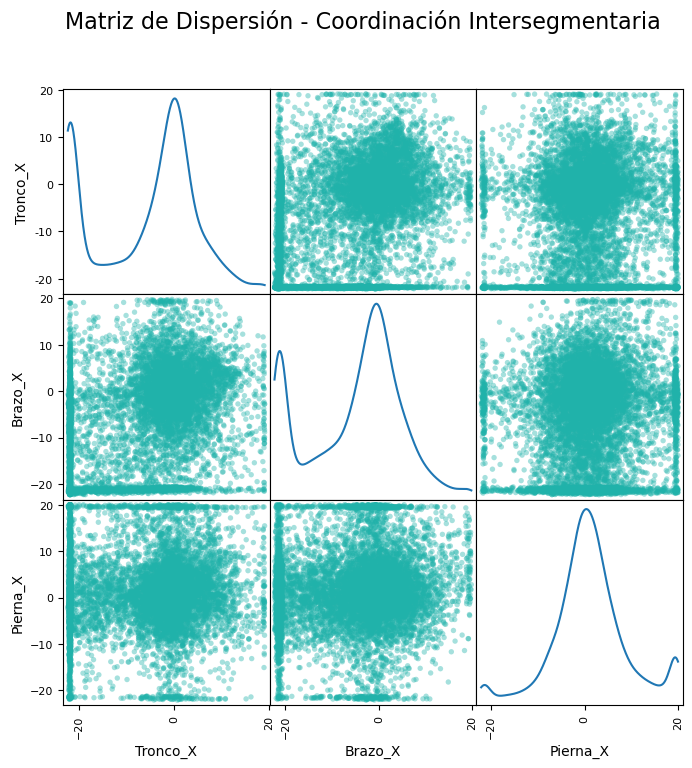

In [12]:
# Selección estratégica: un eje X por segmento corporal
sensores_estrategicos = [
    "chest_acc_x",   # Tronco
    "arm_acc_x",     # Brazo derecho
    "ankle_acc_x"    # Pierna
]

datos_scatter = DATASET_SENSORES_ACTIVIDAD[sensores_estrategicos].copy()


datos_scatter.columns = [
    "Tronco_X",
    "Brazo_X",
    "Pierna_X"
]

pd.plotting.scatter_matrix(
    datos_scatter,
    alpha=0.4,
    figsize=(8, 8),
    diagonal='kde',
    color='lightseagreen',
    marker='o',
    s=15
)

plt.suptitle(
    'Matriz de Dispersión - Coordinación Intersegmentaria',
    fontsize=16
)

plt.show()

<h1>Matriz de dispersión por sujeto</h1>

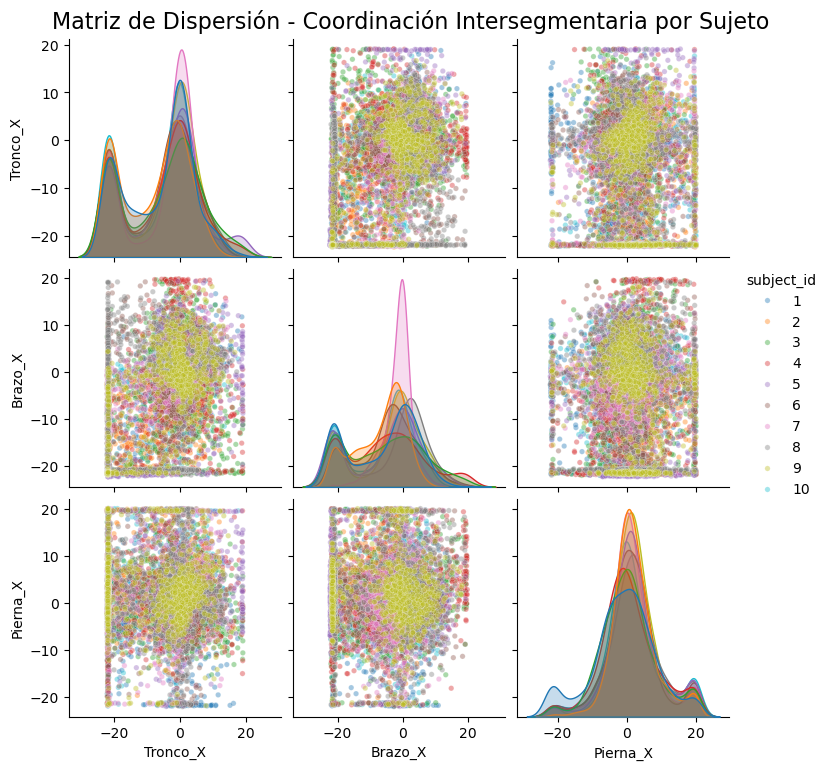

In [13]:
# Selección estratégica
sensores_estrategicos = [
    "chest_acc_x",   # Tronco
    "arm_acc_x",     # Brazo derecho
    "ankle_acc_x"    # Pierna
]

datos_scatter = DATASET_SENSORES_ACTIVIDAD[sensores_estrategicos + ["subject_id"]].copy()

datos_scatter.columns = [
    "Tronco_X",
    "Brazo_X",
    "Pierna_X",
    "subject_id"
]

# Convertir a categoría (importante para que seaborn lo trate como grupo)
datos_scatter["subject_id"] = datos_scatter["subject_id"].astype("category")

# Pairplot con color por sujeto
sns.pairplot(
    datos_scatter,
    vars=["Tronco_X", "Brazo_X", "Pierna_X"],
    hue="subject_id",
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15}
)

plt.suptitle(
    'Matriz de Dispersión - Coordinación Intersegmentaria por Sujeto',
    y=1.02,
    fontsize=16
)

plt.show()